In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
72,6.3,2.5,4.9,1.5,1
103,6.3,2.9,5.6,1.8,2
55,5.7,2.8,4.5,1.3,1
91,6.1,3.0,4.6,1.4,1
133,6.3,2.8,5.1,1.5,2


In [4]:
df.shape

(150, 5)

In [5]:
x = df.drop('target',axis=1)
y = df['target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y, test_size=0.2)

In [9]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [10]:
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

c:\Users\nikpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

In [ ]:
dnn_history = dnn_model.fit(x_train_scaled, y_train, epochs=60, verbose=1,
                            validation_split=0.2, batch_size=10)

In [15]:
dnn_loss, dnn_accuracy = dnn_model.evaluate(x_test_scaled, y_test)
print("Test accuracy:",dnn_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9667 - loss: 0.0884
Test accuracy: 0.9666666388511658


In [16]:
dnn_probs = dnn_model.predict(x_test_scaled)
print(dnn_probs[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
[9.9939394e-01 5.9434806e-04 1.1654935e-05]


In [17]:
predicted_classes = np.argmax(dnn_probs, axis=1)
print(predicted_classes)


[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


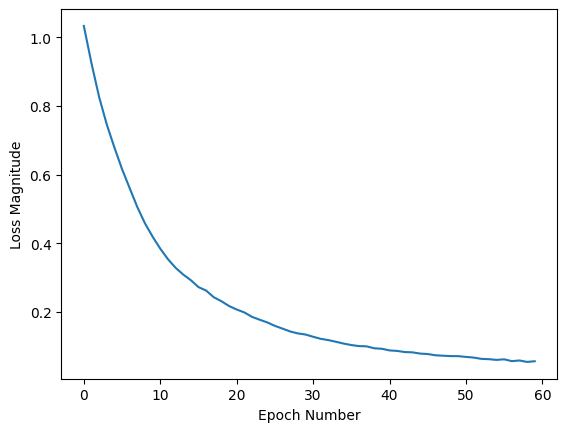

In [18]:
import matplotlib.pyplot as plt
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(dnn_history.history['loss'])